In [1]:
import os
import numpy as np
import pandas as pd
from scipy.io import arff

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, log_loss
)

import matplotlib.pyplot as plt


from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
DATASET_PATH = "/content/drive/MyDrive/CSCI218 2026/Rice_Cammeo_Osmancik.arff"

if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(f"File not found: {DATASET_PATH}\n"
                            f"Please check your Drive path and filename.")

print("Found dataset at:", DATASET_PATH)


Found dataset at: /content/drive/MyDrive/CSCI218 2026/Rice_Cammeo_Osmancik.arff


In [16]:
data, meta = arff.loadarff(DATASET_PATH)
df = pd.DataFrame(data)

for col in df.columns:
    if df[col].dtype == object:
        df[col] = df[col].apply(lambda x: x.decode("utf-8") if isinstance(x, (bytes, bytearray)) else x)

# new feature
df["Convex_Area_Ratio"] = df["Convex_Area"] / df["Area"]

print("Dataset loaded:", df.shape)
df.head()


Dataset loaded: (3810, 9)


,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class,Convex_Area_Ratio
0,15231.0,525.578979,229.749878,85.093788,0.928882,15617.0,0.572896,Cammeo,1.025343
1,14656.0,494.311005,206.020065,91.730972,0.895405,15072.0,0.615436,Cammeo,1.028384
2,14634.0,501.122009,214.106781,87.768288,0.912118,14954.0,0.693259,Cammeo,1.021867
3,13176.0,458.342987,193.337387,87.448395,0.891861,13368.0,0.640669,Cammeo,1.014572
4,14688.0,507.166992,211.743378,89.312454,0.906691,15262.0,0.646024,Cammeo,1.039080


In [4]:
print(df.info())

target_col = "Class"

print("\nClass distribution:")
print(df[target_col].value_counts())

print("\nNumeric summary:")
display(df.describe())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3810 entries, 0 to 3809
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Area               3810 non-null   float64
 1   Perimeter          3810 non-null   float64
 2   Major_Axis_Length  3810 non-null   float64
 3   Minor_Axis_Length  3810 non-null   float64
 4   Eccentricity       3810 non-null   float64
 5   Convex_Area        3810 non-null   float64
 6   Extent             3810 non-null   float64
 7   Class              3810 non-null   object 
 8   Convex_Area_Ratio  3810 non-null   float64
dtypes: float64(8), object(1)
memory usage: 268.0+ KB
None

Class distribution:
Class
Osmancik    2180
Cammeo      1630
Name: count, dtype: int64

Numeric summary:


,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Convex_Area_Ratio
count,3810.000000,3810.000000,3810.000000,3810.000000,3810.000000,3810.000000,3810.000000,3810.000000
mean,12667.727559,454.239180,188.776222,86.313750,0.886871,12952.496850,0.661934,1.022437
std,1732.367706,35.597081,17.448679,5.729817,0.020818,1776.972042,0.077239,0.006429
min,7551.000000,359.100006,145.264465,59.532406,0.777233,7723.000000,0.497413,1.009835
25%,11370.500000,426.144753,174.353855,82.731695,0.872402,11626.250000,0.598862,1.017467
50%,12421.500000,448.852493,185.810059,86.434647,0.889050,12706.500000,0.645361,1.021640
75%,13950.000000,483.683746,203.550438,90.143677,0.902588,14284.000000,0.726562,1.026425
max,18913.000000,548.445984,239.010498,107.542450,0.948007,19099.000000,0.861050,1.079596


In [5]:
# Prepare X / y

X = df.drop(columns=[target_col]).values  # includes Convex_Area_Ratio
y = df[target_col].values

print("X shape:", X.shape)
print("y example:", y[:10])
print("Unique labels:", np.unique(y))


X shape: (3810, 8)
y example: ['Cammeo' 'Cammeo' 'Cammeo' 'Cammeo' 'Cammeo' 'Cammeo' 'Cammeo' 'Cammeo'
 'Cammeo' 'Cammeo']
Unique labels: ['Cammeo' 'Osmancik']


In [6]:
# Split train/val/test (60/20/20, stratified)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("Train/Val/Test sizes:", len(y_train), len(y_val), len(y_test))


Train/Val/Test sizes: 2286 762 762


In [7]:
# Label Encoding

label_encoder = LabelEncoder()

y_train_enc = label_encoder.fit_transform(y_train)
y_val_enc   = label_encoder.transform(y_val)
y_test_enc  = label_encoder.transform(y_test)

print("Class mapping:")
for cls, idx in zip(label_encoder.classes_, range(len(label_encoder.classes_))):
    print(f"{cls} -> {idx}")


Class mapping:
Cammeo -> 0
Osmancik -> 1


In [8]:
#  Standardize features

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

In [9]:
# Build MLP model

EPOCHS = 80
mlp = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    learning_rate_init=1e-3,
    max_iter=1,          # Each fit only runs one iteration
    warm_start=True,     # Continue training with the next fit based on the previous weight
    random_state=42
)

train_loss_list, val_loss_list, test_loss_list = [], [], []
train_acc_list,  val_acc_list,  test_acc_list  = [], [], []

for epoch in range(1, EPOCHS + 1):
    mlp.fit(X_train_s, y_train_enc)

    # --- Probabilities for log_loss ---
    p_train = mlp.predict_proba(X_train_s)
    p_val   = mlp.predict_proba(X_val_s)
    p_test  = mlp.predict_proba(X_test_s)

    # --- Predictions for accuracy ---
    y_train_pred = np.argmax(p_train, axis=1)
    y_val_pred   = np.argmax(p_val, axis=1)
    y_test_pred  = np.argmax(p_test, axis=1)

    # --- loss ---
    train_loss_list.append(log_loss(y_train_enc, p_train))
    val_loss_list.append(log_loss(y_val_enc, p_val))
    test_loss_list.append(log_loss(y_test_enc, p_test))

    # --- accuracy ---
    train_acc_list.append(accuracy_score(y_train_enc, y_train_pred))
    val_acc_list.append(accuracy_score(y_val_enc, y_val_pred))
    test_acc_list.append(accuracy_score(y_test_enc, y_test_pred))

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | "
              f"Train Acc={train_acc_list[-1]:.4f}, Val Acc={val_acc_list[-1]:.4f}, Test Acc={test_acc_list[-1]:.4f} | "
              f"Train Loss={train_loss_list[-1]:.4f}, Val Loss={val_loss_list[-1]:.4f}, Test Loss={test_loss_list[-1]:.4f}")


Epoch   1 | Train Acc=0.4278, Val Acc=0.4278, Test Acc=0.4278 | Train Loss=0.8014, Val Loss=0.8130, Test Loss=0.8037


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691

Epoch  10 | Train Acc=0.9265, Val Acc=0.9055, Test Acc=0.9278 | Train Loss=0.2127, Val Loss=0.2379, Test Loss=0.2229
Epoch  20 | Train Acc=0.9335, Val Acc=0.9160, Test Acc=0.9304 | Train Loss=0.1756, Val Loss=0.1961, Test Loss=0.1835


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691

Epoch  30 | Train Acc=0.9318, Val Acc=0.9147, Test Acc=0.9331 | Train Loss=0.1741, Val Loss=0.1982, Test Loss=0.1810


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691

Epoch  40 | Train Acc=0.9326, Val Acc=0.9134, Test Acc=0.9331 | Train Loss=0.1735, Val Loss=0.2017, Test Loss=0.1812
Epoch  50 | Train Acc=0.9326, Val Acc=0.9134, Test Acc=0.9331 | Train Loss=0.1732, Val Loss=0.2043, Test Loss=0.1818
Epoch  60 | Train Acc=0.9344, Val Acc=0.9160, Test Acc=0.9318 | Train Loss=0.1729, Val Loss=0.2059, Test Loss=0.1824
Epoch  70 | Train Acc=0.9344, Val Acc=0.9160, Test Acc=0.9318 | Train Loss=0.1725, Val Loss=0.2071, Test Loss=0.1830
Epoch  80 | Train Acc=0.9344, Val Acc=0.9160, Test Acc=0.9318 | Train Loss=0.1721, Val Loss=0.2082, Test Loss=0.1834


In [10]:
# Validation metrics (final epoch)
y_val_pred = mlp.predict(X_val_s)

val_acc  = val_acc_list[-1]
val_prec = precision_score(y_val_enc, y_val_pred, average="macro", zero_division=0)
val_rec  = recall_score(y_val_enc, y_val_pred, average="macro", zero_division=0)
val_f1   = f1_score(y_val_enc, y_val_pred, average="macro", zero_division=0)

print("Validation Metrics (macro)")
print(f"Accuracy : {val_acc:.4f}")
print(f"Precision: {val_prec:.4f}")
print(f"Recall   : {val_rec:.4f}")
print(f"F1-score : {val_f1:.4f}")


Validation Metrics (macro)
Accuracy : 0.9160
Precision: 0.9140
Recall   : 0.9146
F1-score : 0.9143


In [11]:
# Test metrics + report (final epoch)

y_pred = mlp.predict(X_test_s)

acc  = test_acc_list[-1]
prec = precision_score(y_test_enc, y_pred, average="macro", zero_division=0)
rec  = recall_score(y_test_enc, y_pred, average="macro", zero_division=0)
f1   = f1_score(y_test_enc, y_pred, average="macro", zero_division=0)

print("Test Metrics (macro)")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")

print("\nClassification Report")
print(classification_report(y_test_enc, y_pred, target_names=label_encoder.classes_, zero_division=0))


Test Metrics (macro)
Accuracy : 0.9318
Precision: 0.9324
Recall   : 0.9280
F1-score : 0.9300

Classification Report
              precision    recall  f1-score   support

      Cammeo       0.94      0.90      0.92       326
    Osmancik       0.93      0.95      0.94       436

    accuracy                           0.93       762
   macro avg       0.93      0.93      0.93       762
weighted avg       0.93      0.93      0.93       762



Label order: ['Cammeo' 'Osmancik']
Confusion Matrix:
 [[294  32]
 [ 20 416]]

Most confused direction: Cammeo -> Osmancik: 32 times


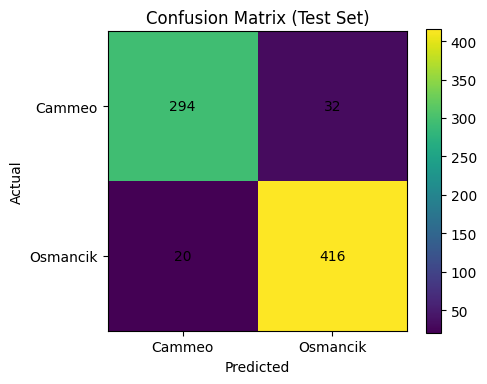

In [12]:
# Confusion Matrix + Most Confused Direction + Plot

cm = confusion_matrix(y_test_enc, y_pred)
labels = label_encoder.classes_

print("Label order:", labels)
print("Confusion Matrix:\n", cm)

def most_confused_direction(cm, class_names):
    cm2 = cm.copy()
    np.fill_diagonal(cm2, 0)
    i, j = np.unravel_index(np.argmax(cm2), cm2.shape)
    return class_names[i], class_names[j], int(cm2[i, j])

c1, c2, count = most_confused_direction(cm, labels)
print(f"\nMost confused direction: {c1} -> {c2}: {count} times")

# Plot (matplotlib only)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm)

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix (Test Set)")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.colorbar(im)
plt.tight_layout()
plt.show()


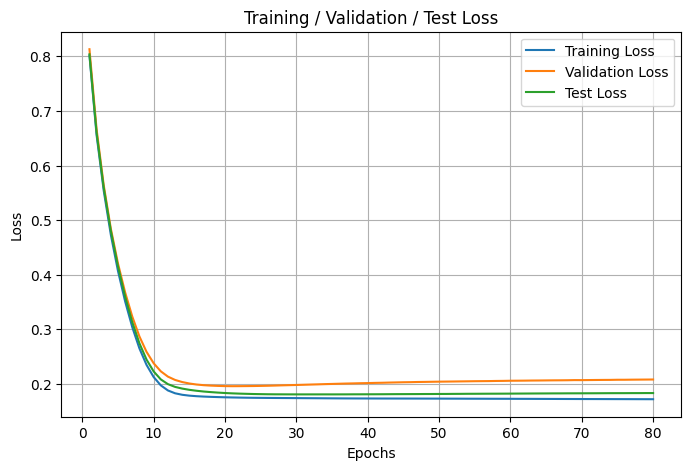

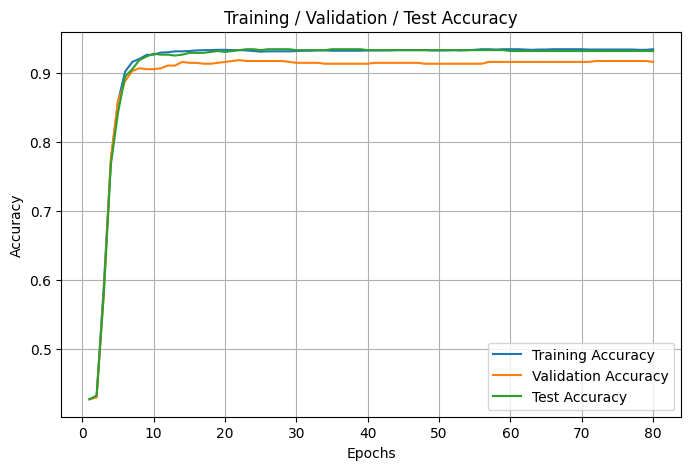

In [13]:
epochs = range(1, len(train_loss_list) + 1)

# 1) Loss curves
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss_list, label="Training Loss")
plt.plot(epochs, val_loss_list, label="Validation Loss")
plt.plot(epochs, test_loss_list, label="Test Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training / Validation / Test Loss")
plt.legend()
plt.grid(True)
plt.show()

# 2) Accuracy curves
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_acc_list, label="Training Accuracy")
plt.plot(epochs, val_acc_list, label="Validation Accuracy")
plt.plot(epochs, test_acc_list, label="Test Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training / Validation / Test Accuracy")
plt.legend()
plt.grid(True)
plt.show()
